# 04 · Del pronóstico a la decisión de inventario

Un pronóstico no vale por su error sino por la decisión que permite tomar. Aquí cada
pronóstico se convierte en una política de inventario y se **simula** contra la demanda
real de las 12 semanas de evaluación.

**Política (s, S) con revisión diaria y ventas perdidas**

| Elemento | Cálculo |
| --- | --- |
| Safety stock | `SS = z(nivel de servicio) · σ(error) · √L` |
| Punto de reorden | `ROP = demanda esperada en el lead time + SS` |
| Lote | EOQ, acotado entre 1 y 14 días de demanda (perecederos) |
| Regla | Si la posición de inventario ≤ ROP, pedir hasta `ROP + lote` |

**Tres políticas, misma mecánica y misma cadencia de actualización (cada 28 días):**

- **Clásica:** media y desviación de la demanda de los últimos 56 días (lo que haría una
  hoja de cálculo).
- **SeasonalNaive** y **LightGBM:** demanda esperada = pronóstico; σ = error del pronóstico
  medido en ventanas *anteriores* a la que se simula.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))

import matplotlib.pyplot as plt
import pandas as pd

from src import config
from src.inventory import policy as pol
from src.utils import plotting as pl

pl.use_style()
LT, SL = config.DEFAULT_LEAD_TIME, config.DEFAULT_SERVICE_LEVEL
CLASSIC, NAIVE, LGBM = pol.POLICIES
COLORS = {CLASSIC: pl.ORANGE, NAIVE: pl.AQUA, LGBM: pl.BLUE}

scenarios = pd.read_parquet(config.SIM_SCENARIOS)
frontier = pd.read_parquet(config.SIM_FRONTIER)
by_sku = pd.read_parquet(config.SIM_BY_SKU)
costs = pd.read_parquet(config.SIM_COSTS)
table = pd.read_parquet(config.POLICY_TABLE)

pd.DataFrame(
    {
        "Supuesto": ["Costo unitario", "Costo de mantener", "Costo fijo por pedido", "Cobertura máxima del lote"],
        "Valor": [
            f"{config.UNIT_COST_RATIO:.0%} del precio de venta",
            f"{config.HOLDING_RATE_ANNUAL:.0%} anual del costo",
            f"USD {config.ORDER_COST:.2f}",
            f"{config.MAX_COVER_DAYS} días",
        ],
    }
)

,Supuesto,Valor
0,Costo unitario,70% del precio de venta
1,Costo de mantener,25% anual del costo
2,Costo fijo por pedido,USD 5.00
3,Cobertura máxima del lote,14 días


M5 no trae costos: los de arriba son **supuestos** y solo afectan el tamaño del lote. Más
abajo se revisa cuánto dependen las conclusiones de ellos.

## 1. Resultado con la fórmula de libro

Lead time de 7 días y nivel de servicio objetivo de 95% (`z = 1.645`).

In [2]:
cols = ["fill_rate", "cycle_service", "skus_meeting_target", "avg_inv_value", "days_of_supply"]
at_target = scenarios.query("lead_time == @LT and service_level == @SL and ss_method == 'sqrt'")
view = at_target.set_index(["group", "policy"])[cols].loc[["Total", "A", "B", "C"]]
view.round(3)

fill_rate  cycle_service  skus_meeting_target  \
group policy                                                                 
Total Clásica (media móvil)      0.948          0.822                0.771   
      SeasonalNaive              0.960          0.868                0.797   
      LightGBM                   0.971          0.897                0.896   
A     Clásica (media móvil)      0.954          0.822                0.827   
      SeasonalNaive              0.964          0.869                0.855   
      LightGBM                   0.968          0.873                0.872   
B     Clásica (media móvil)      0.941          0.849                0.800   
      SeasonalNaive              0.958          0.886                0.814   
      LightGBM                   0.979          0.913                0.895   
C     Clásica (media móvil)      0.907          0.789                0.641   
      SeasonalNaive              0.925          0.844                0.682   
      LightGBM                   0.983          0.927                0.935   

                             avg_inv_value  days_of_supply  
group policy                                                
Total Clásica (media móvil)      72453.789          12.318  
      SeasonalNaive              81374.880          13.885  
      LightGBM                   76705.501          13.112  
A     Clásica (media móvil)      52568.818          11.524  
      SeasonalNaive              58407.465          12.915  
      LightGBM                   53187.479          11.733  
B     Clásica (media móvil)      13705.235          14.263  
      SeasonalNaive              15808.618          16.279  
      LightGBM                   14977.457          15.303  
C     Clásica (media móvil)       6179.735          14.839  
      SeasonalNaive               7158.797          16.947  
      LightGBM                    8540.565          19.659

Tres lecturas:

1. **La meta del proyecto se cumple:** con LightGBM la clase A alcanza 96.8% de fill rate
   (objetivo ≥ 95%) y 87% de sus SKUs lo cumplen individualmente. La política clásica
   también llega a 95.4% en clase A, con un inventario parecido.
2. **Fill rate y nivel de servicio de ciclo no son lo mismo.** `z` fija la probabilidad de
   *no quebrar en un ciclo*; el fill rate mide el % de la demanda atendida. Con `z` de 95%,
   el servicio de ciclo realmente logrado es 82% (clásica) y 90% (LightGBM): la fórmula de
   libro promete más de lo que entrega.
3. **Esta tabla no sirve para comparar políticas**, porque cada una termina en un punto
   distinto: una da más servicio con más inventario, otra menos con menos. La comparación
   válida es *a igual servicio*.

## 2. La comparación justa: curva servicio–inventario

Para cada política se barre el factor de seguridad y se simula. El resultado es una curva:
cuánto inventario promedio cuesta cada punto de fill rate.

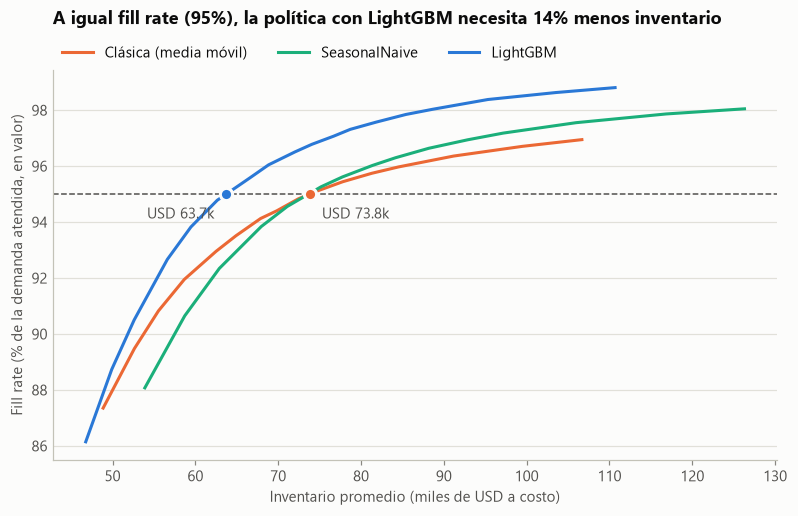

Total  : 73,805 → 63,728 USD (-13.7%)
Clase A: 50,930 → 45,488 USD (-10.7%)


In [3]:
def curve(policy: str, group: str = "Total", lead_time: int = LT, method: str = "sqrt") -> pd.DataFrame:
    g = frontier.query(
        "policy == @policy and group == @group and lead_time == @lead_time and ss_method == @method"
    )
    return g.sort_values("avg_inv_value")


need = pol.inventory_at_fill_rate(frontier, SL)
need_sqrt = need.query("ss_method == 'sqrt'")


def needed(policy: str, group: str = "Total", lead_time: int = LT) -> float:
    row = need_sqrt.query("policy == @policy and group == @group and lead_time == @lead_time")
    return float(row["avg_inv_value"].iloc[0])


saving = needed(LGBM) / needed(CLASSIC) - 1
saving_a = needed(LGBM, "A") / needed(CLASSIC, "A") - 1

fig, ax = plt.subplots(figsize=(8.5, 4.6))
for policy in pol.POLICIES:
    c = curve(policy).query("fill_rate >= 0.86")
    ax.plot(c["avg_inv_value"] / 1000, c["fill_rate"] * 100, color=COLORS[policy], label=policy)
ax.axhline(SL * 100, color=pl.INK_SECONDARY, linewidth=1, linestyle="--")
for policy in (CLASSIC, LGBM):
    x = needed(policy) / 1000
    ax.plot([x], [SL * 100], marker="o", markersize=8, color=COLORS[policy],
            markeredgecolor=pl.SURFACE, markeredgewidth=2)
    left = policy == LGBM
    ax.annotate(f"USD {x:.1f}k", (x, SL * 100), xytext=(-8 if left else 8, -16),
                textcoords="offset points", ha="right" if left else "left", color=pl.INK_SECONDARY)
ax.set_title(
    f"A igual fill rate ({SL:.0%}), la política con LightGBM necesita {abs(saving):.0%} menos inventario",
    pad=30,
)
ax.set_xlabel("Inventario promedio (miles de USD a costo)")
ax.set_ylabel("Fill rate (% de la demanda atendida, en valor)")
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.0), ncols=3, borderaxespad=0.2)
pl.save(fig, "16_frontera_servicio_inventario")
plt.show()

print(f"Total  : {needed(CLASSIC):,.0f} → {needed(LGBM):,.0f} USD ({saving:+.1%})")
print(f"Clase A: {needed(CLASSIC, 'A'):,.0f} → {needed(LGBM, 'A'):,.0f} USD ({saving_a:+.1%})")

**Resultado principal.** Para atender el 95% de la demanda con 7 días de lead time, la
política basada en LightGBM necesita USD 63.7k de inventario promedio contra USD 73.8k de
la política clásica: **14% menos** (11% menos en la clase A). SeasonalNaive no aporta nada
sobre la política clásica: un pronóstico solo ayuda al inventario si es mejor que el
promedio.

## 3. ¿Se sostiene en otros escenarios?

Inventario necesario para alcanzar cada fill rate objetivo, por lead time. `NaN` significa
que la política no alcanza ese servicio con ningún factor de seguridad del barrido.

In [4]:
rows = []
for target in (0.90, 0.95, 0.98):
    n = pol.inventory_at_fill_rate(frontier, target).query("ss_method == 'sqrt' and group == 'Total'")
    piv = n.pivot(index="lead_time", columns="policy", values="avg_inv_value")
    piv["objetivo"] = target
    rows.append(piv.reset_index())
sens = pd.concat(rows).set_index(["objetivo", "lead_time"])[list(pol.POLICIES)]
sens["LightGBM vs clásica"] = sens[LGBM] / sens[CLASSIC] - 1
sens.round({CLASSIC: 0, NAIVE: 0, LGBM: 0, "LightGBM vs clásica": 3})

policy              Clásica (media móvil)  SeasonalNaive  LightGBM  \
objetivo lead_time                                                   
0.90     3                        43847.0        46655.0   42995.0   
         7                        53763.0        57503.0   51843.0   
         14                       73694.0        82461.0   71359.0   
0.95     3                        53422.0        56338.0   49475.0   
         7                        73805.0        73662.0   63728.0   
         14                      118189.0       115442.0   92032.0   
0.98     3                            NaN        77113.0   59652.0   
         7                            NaN       123844.0   88104.0   
         14                           NaN            NaN       NaN   

policy              LightGBM vs clásica  
objetivo lead_time                       
0.90     3                       -0.019  
         7                       -0.036  
         14                      -0.032  
0.95     3                       -0.074  
         7                       -0.137  
         14                      -0.221  
0.98     3                          NaN  
         7                          NaN  
         14                         NaN

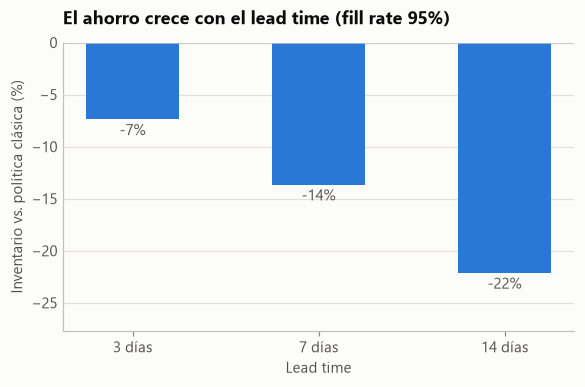

In [5]:
red = sens.xs(SL, level="objetivo")["LightGBM vs clásica"] * 100

fig, ax = plt.subplots(figsize=(6, 3.4))
bars = ax.bar([f"{lt} días" for lt in red.index], red.to_numpy(), width=0.5, color=pl.BLUE)
ax.bar_label(bars, labels=[f"{v:.0f}%" for v in red], padding=3, color=pl.INK_SECONDARY)
ax.axhline(0, color=pl.AXIS, linewidth=1)
ax.set_title(f"El ahorro crece con el lead time (fill rate {SL:.0%})")
ax.set_xlabel("Lead time")
ax.set_ylabel("Inventario vs. política clásica (%)")
ax.set_ylim(red.min() * 1.25, 0)
pl.save(fig, "17_ahorro_por_lead_time")
plt.show()

- **El ahorro crece con el lead time:** 7% con 3 días, 14% con 7 y 22% con 14. Cuanto más
  lejos hay que mirar, más vale un pronóstico que conoce el calendario.
- **Y con la exigencia de servicio:** a 90% de fill rate la diferencia es de solo 2–4%
  (casi cualquier política llega); a 98% la política clásica ya no llega con ningún factor
  de seguridad del barrido.
- Con 14 días de lead time, ninguna política alcanza 98%.

## 4. Escenarios: lead time × nivel de servicio (clase A, LightGBM)

In [6]:
grid = scenarios.query("policy == @LGBM and ss_method == 'sqrt' and group == 'A'")
grid.pivot(index="lead_time", columns="service_level",
           values=["fill_rate", "cycle_service", "avg_inv_value"]).round(3)

fill_rate               cycle_service                \
service_level      0.90   0.95   0.99          0.90   0.95   0.99   
lead_time                                                           
3                 0.982  0.985  0.988         0.878  0.907  0.939   
7                 0.962  0.968  0.976         0.837  0.873  0.910   
14                0.944  0.951  0.961         0.806  0.840  0.889   

              avg_inv_value                        
service_level          0.90       0.95       0.99  
lead_time                                          
3                 43229.890  45287.593  49133.202  
7                 50086.364  53187.479  58930.993  
14                62445.810  66527.960  74466.569

En la clase A el fill rate supera 95% en ocho de los nueve escenarios; solo queda corto con
14 días de lead time y `z` de 90%. Subir el nivel nominal de 90% a 99% cuesta entre 14% y
19% más inventario.

## 5. ¿Importa cómo se calcula el safety stock?

La fórmula de libro supone errores diarios independientes y normales. Se comparan tres
formas de medir la incertidumbre en el lead time:

| Método | Safety stock |
| --- | --- |
| `sqrt` | `z · σ(error diario) · √L` — la fórmula de libro |
| `acumulado` | `z · σ(error acumulado en L días)` — mide la correlación entre días |
| `empirico` | cuantil empírico del error acumulado en L días — sin supuesto de normalidad |

In [7]:
methods = scenarios.query("lead_time == @LT and service_level == @SL and group == 'Total'")
calib = methods.pivot(index="ss_method", columns="policy", values="cycle_service")[list(pol.POLICIES)]
eff = need.query("lead_time == @LT and group == 'Total'").pivot(
    index="ss_method", columns="policy", values="avg_inv_value"
)[list(pol.POLICIES)]
pd.concat({"Servicio de ciclo logrado (nominal 95%)": calib.round(3),
           "Inventario para 95% de fill rate (USD)": eff.round(0)}, axis=1)

Servicio de ciclo logrado (nominal 95%)                         \
policy                      Clásica (media móvil) SeasonalNaive LightGBM   
ss_method                                                                  
acumulado                                   0.833         0.875    0.918   
empirico                                    0.861         0.885    0.915   
sqrt                                        0.822         0.868    0.897   

          Inventario para 95% de fill rate (USD)                         
policy                     Clásica (media móvil) SeasonalNaive LightGBM  
ss_method                                                                
acumulado                                71024.0       72887.0  63660.0  
empirico                                 71341.0       79892.0  66473.0  
sqrt                                     73805.0       73662.0  63728.0

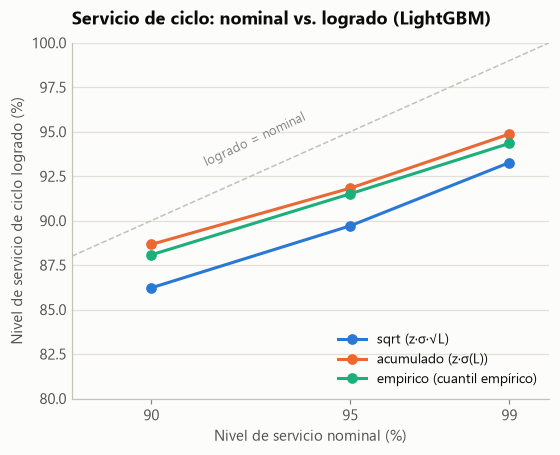

In [8]:
nominal = scenarios.query("lead_time == @LT and group == 'Total' and policy == @LGBM")
piv = nominal.pivot(index="service_level", columns="ss_method", values="cycle_service")

fig, ax = plt.subplots(figsize=(5.6, 4.2))
ax.plot([88, 100], [88, 100], color=pl.AXIS, linewidth=1, linestyle="--")
ax.annotate("logrado = nominal", (92.6, 92.9), ha="center", va="bottom", rotation=25,
            color=pl.MUTED, fontsize=8.5)
for method, color in zip(pol.SS_METHODS, pl.CATEGORICAL, strict=False):
    ax.plot(piv.index * 100, piv[method] * 100, marker="o", color=color,
            label=f"{method} ({pol.SS_METHODS[method]})")
ax.set_title("Servicio de ciclo: nominal vs. logrado (LightGBM)")
ax.set_xlabel("Nivel de servicio nominal (%)")
ax.set_ylabel("Nivel de servicio de ciclo logrado (%)")
ax.set_xticks([90, 95, 99])
ax.set_xlim(88, 100)
ax.set_ylim(80, 100)
ax.legend(loc="lower right", fontsize=9)
pl.save(fig, "18_servicio_nominal_vs_logrado")
plt.show()

Un resultado que no esperaba: **los métodos más sofisticados no hacen la política más
eficiente.**

- **Eficiencia (inventario para 95% de fill rate):** con LightGBM, la fórmula de libro y el
  σ acumulado necesitan lo mismo (USD 63.7k); el cuantil empírico necesita 4% *más*, porque
  estimar un cuantil extremo por SKU con tan pocas muestras mete ruido.
- **Calibración (¿se cumple lo que promete `z`?):** aquí sí hay diferencia. Con la fórmula
  de libro el servicio de ciclo queda en 90% cuando se pide 95%; con σ acumulado sube a
  92%. Ninguno llega a lo nominal.

Es decir: el método de safety stock mueve *en qué punto* de la curva cae la política, no la
curva. Lo que mueve la curva es la calidad del pronóstico. En la práctica conviene fijar
el factor de seguridad **por simulación** contra el fill rate deseado, en vez de confiar en
la lectura nominal de `z`.

## 6. Por clase ABC

In [9]:
by_class = need_sqrt.query("lead_time == @LT").pivot(index="group", columns="policy", values="avg_inv_value")
by_class = by_class.loc[["A", "B", "C", "Total"], list(pol.POLICIES)]
by_class["LightGBM vs clásica"] = by_class[LGBM] / by_class[CLASSIC] - 1
by_class.round({CLASSIC: 0, NAIVE: 0, LGBM: 0, "LightGBM vs clásica": 3})

policy,Clásica (media móvil),SeasonalNaive,LightGBM,LightGBM vs clásica
group,,,,
A,50930.0,51173.0,45488.0,-0.107
B,15449.0,14458.0,11555.0,-0.252
C,NaN,9775.0,6611.0,NaN
Total,73805.0,73662.0,63728.0,-0.137


El ahorro relativo es mayor en la clase B (25%) que en la A (11%), y en la clase C la
política clásica no alcanza 95% con ningún factor de seguridad. En dinero, la mayor parte
sigue viniendo de la clase A (USD 5.4k de los 10.1k).

## 7. ¿Qué SKUs no llegan al objetivo?

In [10]:
classes = pd.read_parquet(config.ABC_XYZ)[["unique_id", "pattern"]]
sku = by_sku.query("policy == @LGBM and ss_method == 'sqrt'").merge(classes, on="unique_id")
sku = sku[sku["demand"] > 0].assign(cumple=lambda d: d["fill_rate"] >= SL)
miss = sku.groupby("pattern").agg(
    skus=("unique_id", "size"), cumplen=("cumple", "mean"), fill_rate_mediano=("fill_rate", "median"),
    demanda_diaria=("daily_demand", "median"),
)
miss.round(3)

,skus,cumplen,fill_rate_mediano,demanda_diaria
pattern,,,,
errática,37,0.730,1.0,3.488
intermitente,922,0.901,1.0,0.881
irregular,254,0.870,1.0,1.131
suave,213,0.930,1.0,3.583


In [11]:
sku.groupby("abc").agg(skus=("unique_id", "size"), cumplen=("cumple", "mean"),
                       fill_rate_p10=("fill_rate", lambda s: s.quantile(0.10))).round(3)

,skus,cumplen,fill_rate_p10
abc,,,
A,602,0.872,0.928
B,456,0.895,0.948
C,368,0.935,0.962


La mediana de fill rate por SKU es 100% en todos los patrones: la mayoría de los SKUs no
quiebra nunca en las 12 semanas, y el incumplimiento se concentra en una minoría. El
patrón más difícil es el **errático** (ventas frecuentes de tamaño muy variable): solo 73%
de esos SKUs cumple. En la clase A cumple el 87%, y el 10% peor queda en 93% de fill rate
o menos.

## 8. Sensibilidad a los supuestos de costo

El costo por pedido y el costo de mantener solo entran al tamaño del lote (EOQ). ¿Cambia
la conclusión si los supuestos son otros?

In [12]:
costs.pivot(index="holding_rate_annual", columns="order_cost", values="reduction").round(3)

order_cost,2.5,5.0,10.0
holding_rate_annual,,,
0.15,-0.132,-0.133,-0.130
0.25,-0.130,-0.137,-0.130
0.35,-0.132,-0.128,-0.133


Duplicar o reducir a la mitad el costo por pedido, o mover el costo de mantener entre 15% y
35% anual, deja el ahorro entre 12.8% y 13.7%. La conclusión no depende de los supuestos de
costo, porque afectan por igual el lote de todas las políticas.

## 9. La tabla que recibe el planeador

Política sugerida hoy para cada SKU, con el pronóstico de las próximas 4 semanas
(`data/processed/policy_table.parquet`; es lo que muestra la app).

In [13]:
show = ["unique_id", "segment", "pattern", "forecast_28d", "demand_lead_time", "safety_stock",
        "rop", "lot", "order_up_to"]
table.sort_values("forecast_28d", ascending=False)[show].head(10).round(1)

,unique_id,segment,pattern,forecast_28d,demand_lead_time,safety_stock,rop,lot,order_up_to
698,FOODS_3_090_CA_1,AY,suave,1642.9,378.2,95.0,474.0,822.0,1296.0
728,FOODS_3_120_CA_1,AX,suave,1210.7,261.1,115.0,377.0,426.0,803.0
860,FOODS_3_252_CA_1,AX,suave,1169.9,262.1,42.0,305.0,585.0,890.0
1191,FOODS_3_586_CA_1,AX,suave,1128.3,258.8,39.0,298.0,565.0,863.0
672,FOODS_3_064_CA_1,AX,suave,759.2,180.8,33.0,214.0,380.0,594.0
1171,FOODS_3_566_CA_1,AX,errática,734.4,170.2,47.0,218.0,368.0,586.0
1192,FOODS_3_587_CA_1,AX,suave,668.8,154.7,50.0,205.0,335.0,540.0
902,FOODS_3_295_CA_1,AY,suave,638.0,159.6,46.0,206.0,320.0,526.0
1106,FOODS_3_501_CA_1,AY,errática,635.7,157.7,54.0,212.0,318.0,530.0
889,FOODS_3_282_CA_1,AX,suave,607.5,138.9,53.0,192.0,304.0,496.0
